<a href="https://colab.research.google.com/github/nishmareddy9-alt/SalesDataAnalysis-Visualization/blob/main/SalesDataAnalysis_Visualization1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV dataset
df = pd.read_csv("/content/sales_data.csv")

#Display the data
print(df)

# Display the first five rows
display(df.head())

# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Check column data types and missing values
df.info()
print(df.isnull().sum())

          Date Region        Product     Category  Quantity  Unit_Price  \
0   2026-01-03  North         Laptop  Electronics         2       42000   
1   2026-01-05  South  Notebook Pack   Stationery        15         120   
2   2026-01-07   East   Office Chair    Furniture         3        6500   
3   2026-01-10   West     Headphones  Electronics         5        1800   
4   2026-01-13  North           Desk    Furniture         2        8500   
5   2026-01-16  South        Pen Set   Stationery        20          90   
6   2026-01-19   East        Monitor  Electronics         4       12500   
7   2026-01-22   West      Bookshelf    Furniture         1        7200   
8   2026-01-25  North  Printer Paper   Stationery        12         350   
9   2026-01-28  South     Smartphone  Electronics         3       24000   
10  2026-02-02   East         Laptop  Electronics         1       42000   
11  2026-02-04   West   Office Chair    Furniture         4        6500   
12  2026-02-07  North  No

,Date,Region,Product,Category,Quantity,Unit_Price,Unit_Cost,Revenue,Cost,Profit
0,2026-01-03,North,Laptop,Electronics,2,42000,35000,84000,70000,14000
1,2026-01-05,South,Notebook Pack,Stationery,15,120,65,1800,975,825
2,2026-01-07,East,Office Chair,Furniture,3,6500,4700,19500,14100,5400
3,2026-01-10,West,Headphones,Electronics,5,1800,1100,9000,5500,3500
4,2026-01-13,North,Desk,Furniture,2,8500,6200,17000,12400,4600


Dataset shape: (60, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        60 non-null     object
 1   Region      60 non-null     object
 2   Product     60 non-null     object
 3   Category    60 non-null     object
 4   Quantity    60 non-null     int64 
 5   Unit_Price  60 non-null     int64 
 6   Unit_Cost   60 non-null     int64 
 7   Revenue     60 non-null     int64 
 8   Cost        60 non-null     int64 
 9   Profit      60 non-null     int64 
dtypes: int64(6), object(4)
memory usage: 4.8+ KB
Date          0
Region        0
Product       0
Category      0
Quantity      0
Unit_Price    0
Unit_Cost     0
Revenue       0
Cost          0
Profit        0
dtype: int64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df



,Date,Region,Product,Category,Quantity,Unit_Price,Unit_Cost,Revenue,Cost,Profit
0,2026-01-03,North,Laptop,Electronics,2,42000,35000,84000,70000,14000
1,2026-01-05,South,Notebook Pack,Stationery,15,120,65,1800,975,825
2,2026-01-07,East,Office Chair,Furniture,3,6500,4700,19500,14100,5400
3,2026-01-10,West,Headphones,Electronics,5,1800,1100,9000,5500,3500
4,2026-01-13,North,Desk,Furniture,2,8500,6200,17000,12400,4600
5,2026-01-16,South,Pen Set,Stationery,20,90,35,1800,700,1100
6,2026-01-19,East,Monitor,Electronics,4,12500,9300,50000,37200,12800
7,2026-01-22,West,Bookshelf,Furniture,1,7200,5200,7200,5200,2000
8,2026-01-25,North,Printer Paper,Stationery,12,350,220,4200,2640,1560
9,2026-01-28,South,Smartphone,Electronics,3,24000,19000,72000,57000,15000


In [ ]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Calculate sales metrics
total_revenue = df["Revenue"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_units = df["Quantity"].sum()

print("Total Revenue:", total_revenue)
print("Total Cost:", total_cost)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)

# Profit margin as a percentage
profit_margin = total_profit / total_revenue * 100
print("Profit Margin:", round(profit_margin, 2), "%")

Total Revenue: 1659680
Total Cost: 1277505
Total Profit: 382175
Total Units Sold: 484
Profit Margin: 23.03 %


In [ ]:
category_sales = (
    df.groupby("Category")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Units_Sold=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

display(category_sales)

,Revenue,Profit,Units_Sold
Category,,,
Electronics,1275000,266600,89
Furniture,330200,90700,45
Stationery,54480,24875,350


In [ ]:
product_sales = (
    df.groupby("Product")
      .agg(
          Revenue=("Revenue", "sum"),
          Profit=("Profit", "sum"),
          Units_Sold=("Quantity", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

display(product_sales)

print("Top product:", product_sales["Revenue"].idxmax())

,Revenue,Profit,Units_Sold
Product,,,
Laptop,546000,91000,13
Smartphone,432000,90000,18
Monitor,225000,57600,18
Desk,127500,34500,15
Office Chair,123500,34200,19
Bookshelf,79200,22000,11
Headphones,72000,28000,40
Printer Paper,26250,9750,75
Pen Set,14310,8745,159


Top product: Laptop


In [ ]:
# Region-wise sales
region_sales = df.groupby("Region").agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
)

display(region_sales)

# Extract month from date
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Monthly sales
monthly_sales = df.groupby("Month").agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
)

display(monthly_sales)

,Revenue,Profit
Region,,
East,503840,110550
North,452530,93255
South,336520,85115
West,366790,93255


,Revenue,Profit
Month,,
2026-01,266500,60785
2026-02,201410,50065
2026-03,316440,69380
2026-04,290930,68550
2026-05,266370,63470
2026-06,318030,69925


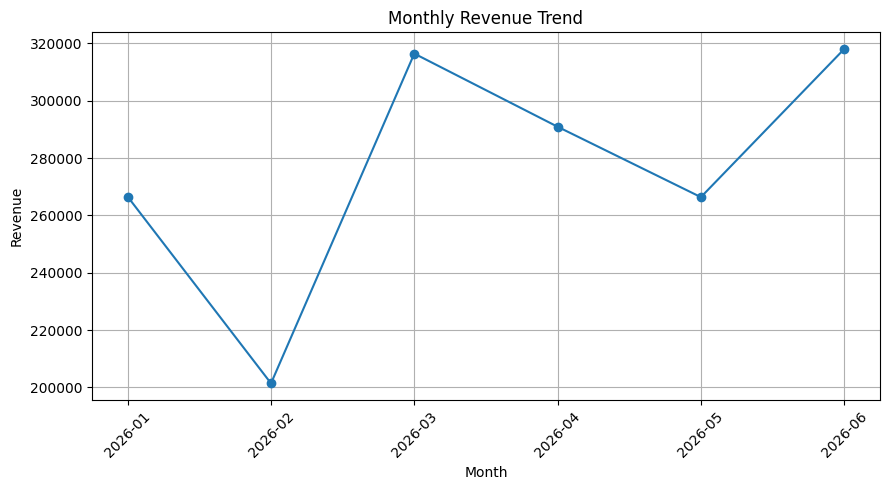

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    monthly_sales.index,
    monthly_sales["Revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

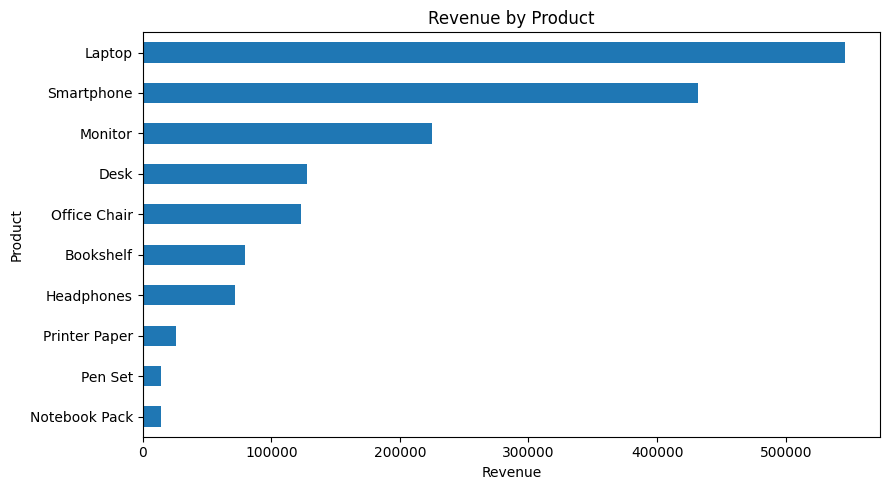

In [ ]:
plt.figure(figsize=(9, 5))
product_sales["Revenue"].sort_values().plot(kind="barh")
plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

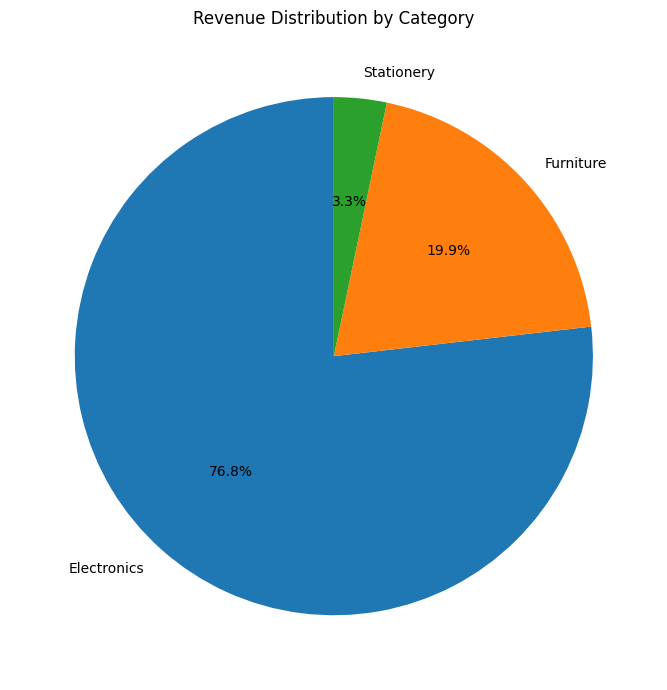

In [ ]:
plt.figure(figsize=(7, 7))
category_sales["Revenue"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Distribution by Category")
plt.ylabel("")
plt.tight_layout()
plt.show()

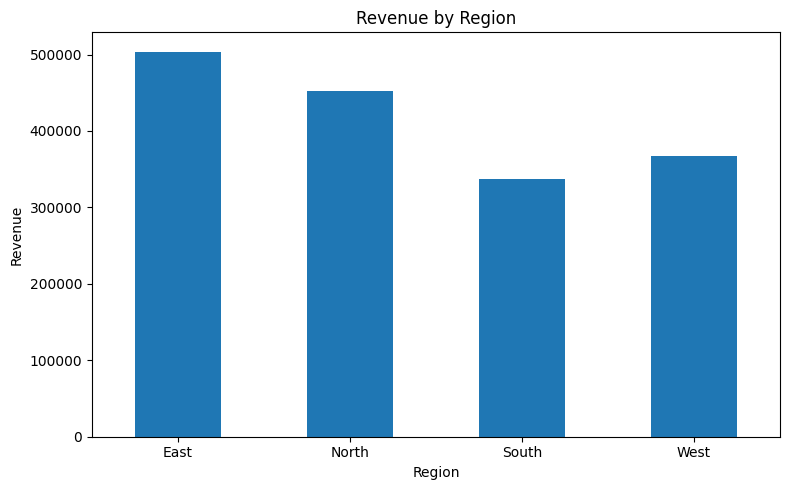

In [ ]:
plt.figure(figsize=(8, 5))
region_sales["Revenue"].plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

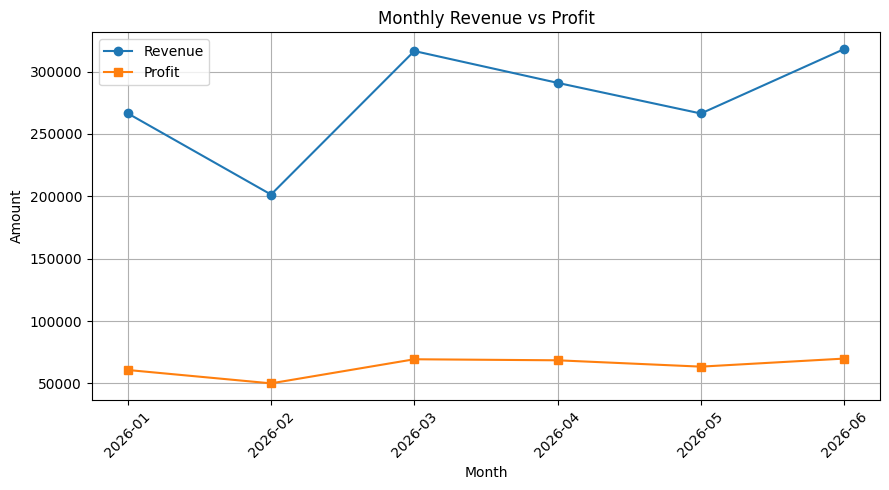

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly_sales.index,
    monthly_sales["Profit"],
    marker="s",
    label="Profit"
)

plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("SALES ANALYSIS INSIGHTS")

print(
    "Highest revenue product:",
    product_sales["Revenue"].idxmax()
)

print(
    "Highest revenue category:",
    category_sales["Revenue"].idxmax()
)

print(
    "Highest revenue region:",
    region_sales["Revenue"].idxmax()
)

print(
    "Best sales month:",
    monthly_sales["Revenue"].idxmax()
)

print(
    "Lowest sales month:",
    monthly_sales["Revenue"].idxmin()
)

print(
    "Most profitable product:",
    product_sales["Profit"].idxmax()
)

SALES ANALYSIS INSIGHTS
Highest revenue product: Laptop
Highest revenue category: Electronics
Highest revenue region: East
Best sales month: 2026-06
Lowest sales month: 2026-02
Most profitable product: Laptop
